# Observations - VERT
L1: s-c

L2: tsh-sh

NOT THIS: In this version, we consider both RC-first and CL-first runs. That is, all four combinations: RCRC, RCCL, CLRC, CLCL. 

In [20]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

In [21]:
# plot for each condition
L1_CONDITION_MAP = {
    "0203_RCRC_VERT_FZ_1e5": "Recon", 
    "0203_RCCL_VERT_FZ_1e5": "Recon",
    "0203_RCRC_VERT_NFZ_1e5": "Recon",
    "0203_RCCL_VERT_NFZ_1e5": "Recon", 
    "0203_CLRC_VERT_FZ_1e5": "Class", 
    "0203_CLCL_VERT_FZ_1e5": "Class",
    "0203_CLRC_VERT_NFZ_1e5": "Class",
    "0203_CLCL_VERT_NFZ_1e5": "Class", 
}

L2_CONDITION_MAP = {
    "0203_RCRC_VERT_FZ_1e5": "Recon", 
    "0203_RCCL_VERT_FZ_1e5": "Class",
    "0203_RCRC_VERT_NFZ_1e5": "Recon",
    "0203_RCCL_VERT_NFZ_1e5": "Class", 
    "0203_CLRC_VERT_FZ_1e5": "Recon", 
    "0203_CLCL_VERT_FZ_1e5": "Class",
    "0203_CLRC_VERT_NFZ_1e5": "Recon",
    "0203_CLCL_VERT_NFZ_1e5": "Class", 
}

FREEZING_CONDITION_MAP = {
    "0203_RCRC_VERT_FZ_1e5": "Freeze", 
    "0203_RCCL_VERT_FZ_1e5": "Freeze",
    "0203_RCRC_VERT_NFZ_1e5": "NoFreeze",
    "0203_RCCL_VERT_NFZ_1e5": "NoFreeze", 
    "0203_CLRC_VERT_FZ_1e5": "Freeze", 
    "0203_CLCL_VERT_FZ_1e5": "Freeze",
    "0203_CLRC_VERT_NFZ_1e5": "NoFreeze",
    "0203_CLCL_VERT_NFZ_1e5": "NoFreeze", 
}

BASE_PATH = "./observations/"
EPOCH_START = 10
EPOCH_END = 200
EVAL_METHOD = "silhouette"
RUNS = [1, 2, 3, 4, 5, 6]

TRAIN_MAP = {
    "tsh_sh": "L2", "s_c": "L1"
}

OBSERVE_INCLUDE = ["0203_RCRC_VERT_FZ_1e5", "0203_RCCL_VERT_FZ_1e5",
                   "0203_RCRC_VERT_NFZ_1e5", "0203_RCCL_VERT_NFZ_1e5"]

integrated_df = pd.DataFrame()
for condition in L1_CONDITION_MAP.keys(): 
    if condition not in OBSERVE_INCLUDE:
        continue
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            file_path = condition_path + f"{EVAL_METHOD}_E{epoch}_R{run}.csv"
            df = pd.read_csv(file_path)
            
            scores = df["sil_score"].tolist()
            train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

            result_df = pd.DataFrame({
                "L1_condition": [L1_CONDITION_MAP[condition]] * len(scores),
                "L2_condition": [L2_CONDITION_MAP[condition]] * len(scores),
                "freezing_condition": [FREEZING_CONDITION_MAP[condition]] * len(scores),
                "contrast_pair": df["sil_type"].tolist(),
                "train_lang": train_langs,
                "sil_score": scores, 
                "run": [run] * len(scores),
                "epoch": [epoch] * len(scores)})
            integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

In [22]:
# integrate L1 and L2 conditions into one column for better visualization
integrated_df["combined_condition"] = integrated_df["L1_condition"] + "_" + integrated_df["L2_condition"]

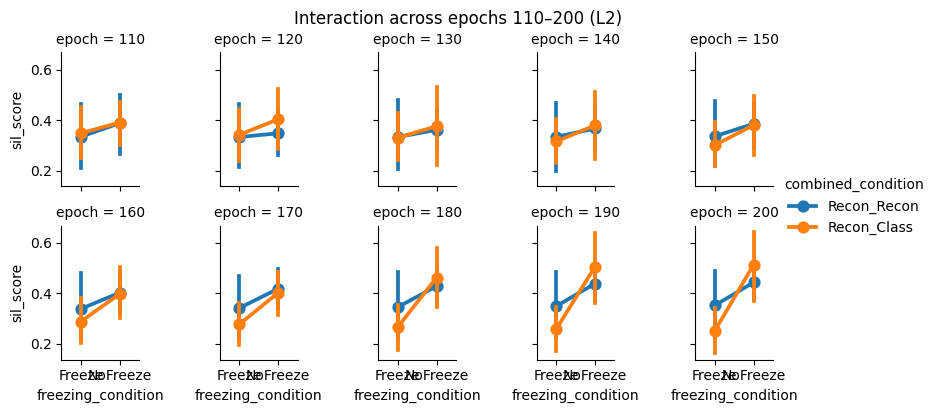

In [23]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = integrated_df.copy()
df = df[df["train_lang"] == "L2"]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freezing_condition",
    y="sil_score",
    hue="combined_condition",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (L2)", y=1.02)
plt.show()

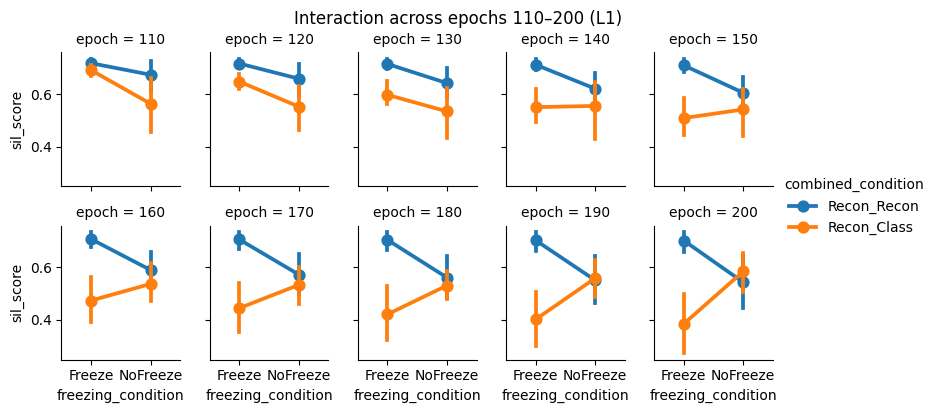

In [24]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = integrated_df.copy()
df = df[df["train_lang"] == "L1"]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freezing_condition",
    y="sil_score",
    hue="combined_condition",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (L1)", y=1.02)
plt.show()

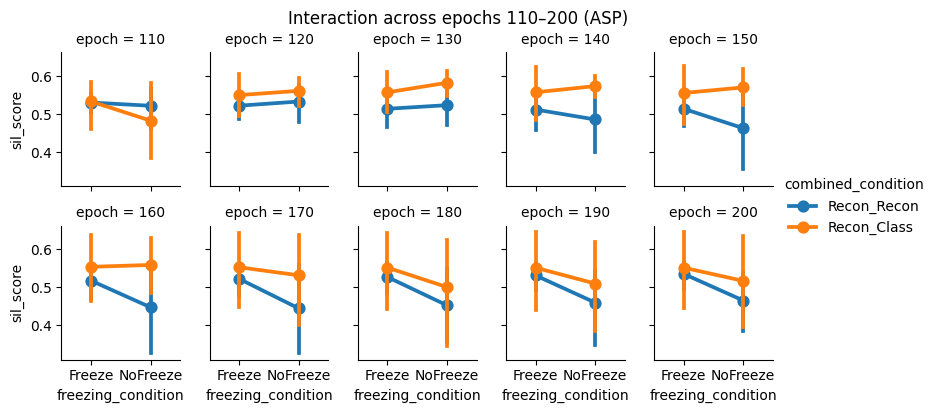

In [25]:
# plot 110 to 200 into one big composed plot
import seaborn as sns
import matplotlib.pyplot as plt
df = integrated_df.copy()
df = df[df["contrast_pair"].isin(["sh_s", "ch_c"])]
df = df[df["epoch"].between(110, 200)]
g = sns.catplot(
    data=df,
    x="freezing_condition",
    y="sil_score",
    hue="combined_condition",
    col="epoch",
    col_wrap=5,
    kind="point",
    ci=95,
    height=2,
    aspect=0.8
)

g.fig.suptitle("Interaction across epochs 110–200 (ASP)", y=1.02)
plt.show()

In [26]:
# # plot 110 to 200 into one big composed plot
# import seaborn as sns
# import matplotlib.pyplot as plt
# for train_lang in ["L1", "L2"]: 
#     df = integrated_df.copy()
#     df = df[df["train_lang"] == train_lang]
#     df = df[df["L1_condition"] == "Recon"]
#     df = df[df["epoch"].between(110, 200)]
#     g = sns.catplot(
#         data=df,
#         x="freezing_condition",
#         y="sil_score",
#         hue="combined_condition",
#         col="epoch",
#         col_wrap=5,
#         kind="point",
#         ci=95,
#         height=2,
#         aspect=0.8
#     )

#     g.fig.suptitle(f"Interaction across epochs 110–200 ({train_lang})", y=1.02)
#     plt.show()

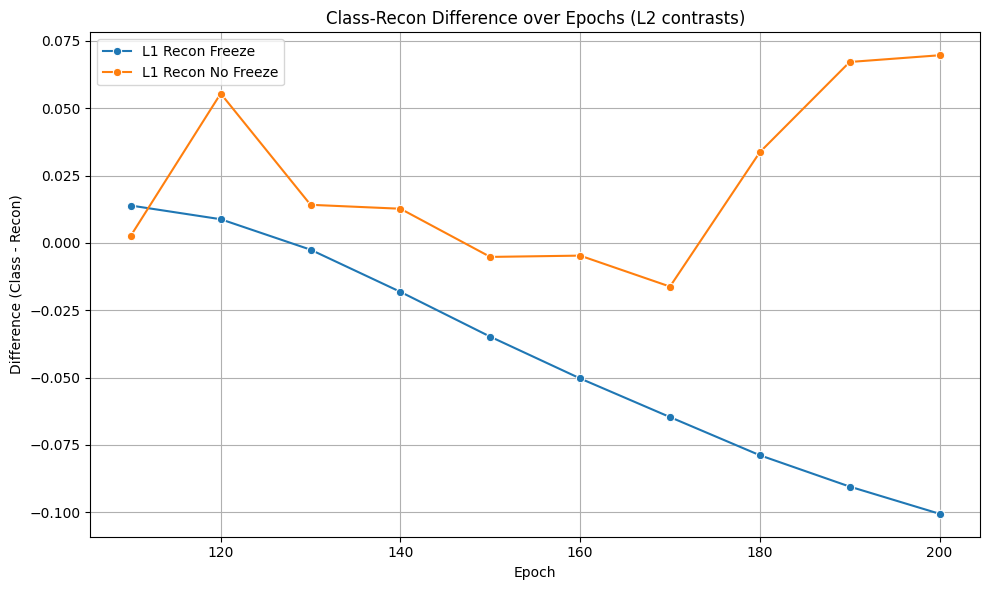

In [27]:
L1_rc_diffs = []
L1_cl_diffs = []
# draw the epoch-development of the interaction effect
df = integrated_df.copy()
for epoch in range(110, EPOCH_END + 1, 10):
    df_epoch = df[df["epoch"] == epoch]
    df_epoch = df_epoch[df_epoch["train_lang"].isin(["L2"])]
    means = df_epoch.groupby(["L1_condition", "L2_condition", "freezing_condition"])["sil_score"].mean()
    L1_rc_diffs.append({"epoch": epoch, 
                        "diff_freeze": means["Recon", "Class", "Freeze"] - means["Recon", "Recon", "Freeze"], 
                        "diff_nofreeze": means["Recon", "Class", "NoFreeze"] - means["Recon", "Recon", "NoFreeze"]})

    # L1_cl_diffs.append({"epoch": epoch, 
    #                     "diff_freeze": means["Class", "Class", "Freeze"] - means["Class", "Recon", "Freeze"], 
    #                     "diff_nofreeze": means["Class", "Class", "NoFreeze"] - means["Class", "Recon", "NoFreeze"]})


L1_rc_diffs_df = pd.DataFrame(L1_rc_diffs)
L1_cl_diffs_df = pd.DataFrame(L1_cl_diffs)

plt.figure(figsize=(10, 6))
sns.lineplot(data=L1_rc_diffs_df, x="epoch", y="diff_freeze", marker="o", label="L1 Recon Freeze")
sns.lineplot(data=L1_rc_diffs_df, x="epoch", y="diff_nofreeze", marker="o", label="L1 Recon No Freeze")

# sns.lineplot(data=L1_cl_diffs_df, x="epoch", y="diff_freeze", marker="s", label="L1 Class Freeze")
# sns.lineplot(data=L1_cl_diffs_df, x="epoch", y="diff_nofreeze", marker="s", label="L1 Class No Freeze")
plt.title("Class-Recon Difference over Epochs (L2 contrasts)")
plt.xlabel("Epoch")
plt.ylabel("Difference (Class - Recon)")
plt.grid(True)
plt.tight_layout()
plt.show()

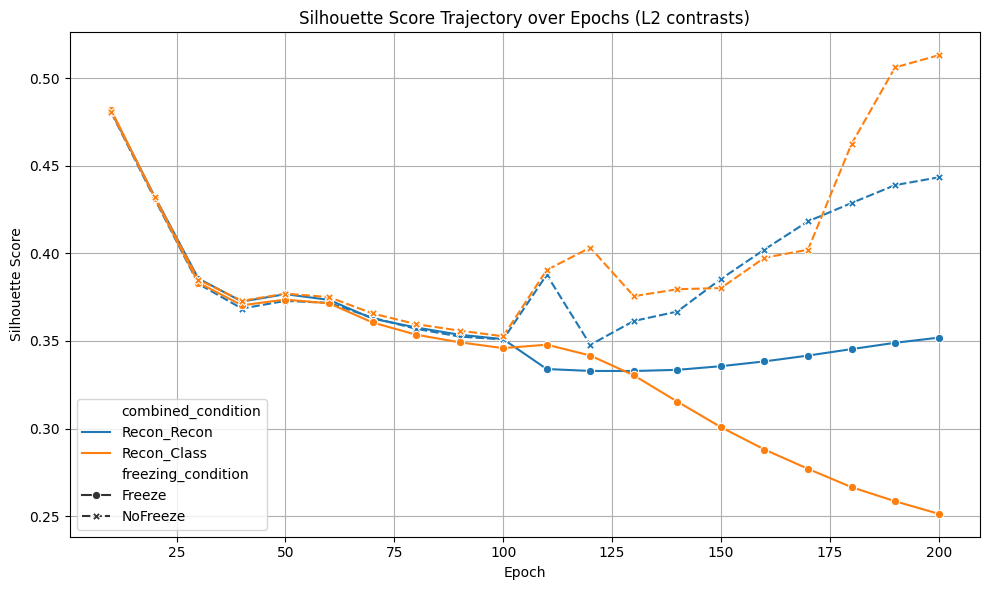

In [28]:
all_plot_df = integrated_df.copy()
# all_plot_df = all_plot_df[all_plot_df["epoch"].between(110, 200)]
all_plot_df = all_plot_df[all_plot_df["train_lang"] == "L2"]

plt.figure(figsize=(10, 6))
# plot trajectory of all conditions (L1_condition, L2_condition, freezing_condition)
sns.lineplot(data=all_plot_df, x="epoch", y="sil_score", hue="combined_condition", style="freezing_condition", markers=True, errorbar=None)

plt.title("Silhouette Score Trajectory over Epochs (L2 contrasts)")
plt.xlabel("Epoch")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

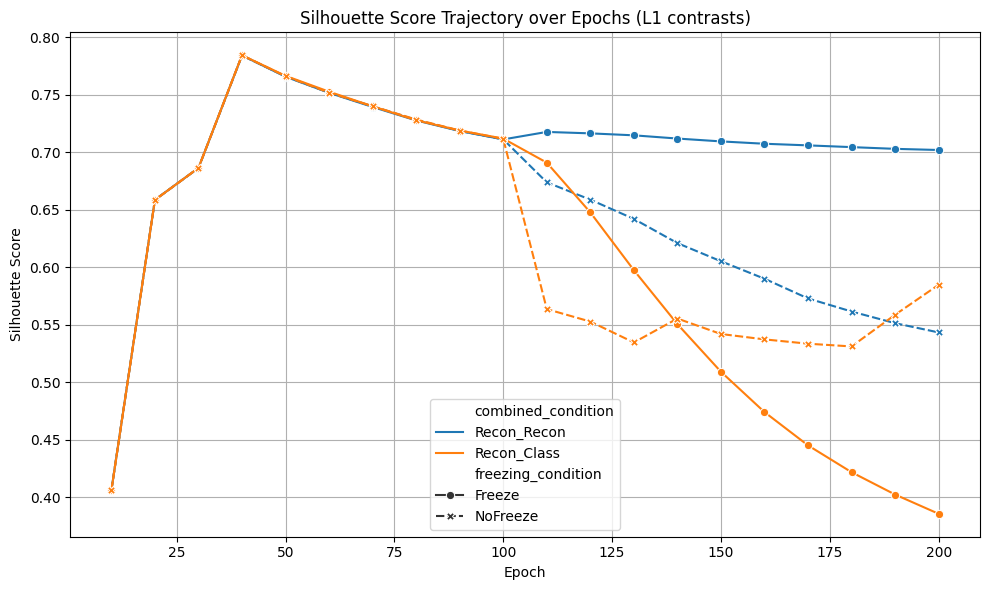

In [ ]:
all_plot_df = integrated_df.copy()
# all_plot_df = all_plot_df[all_plot_df["epoch"].between(110, 200)]
all_plot_df = all_plot_df[all_plot_df["train_lang"] == "L1"]

plt.figure(figsize=(10, 6))
# plot trajectory of all conditions (L1_condition, L2_condition, freezing_condition)
sns.lineplot(data=all_plot_df, x="epoch", y="sil_score", hue="combined_condition", style="freezing_condition", markers=True, errorbar=None)

plt.title("Silhouette Score Trajectory over Epochs (L1 contrasts)")
plt.xlabel("Epoch")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

## Basic observations on learning trajectory
- the geometry of the training tokens seems to affect the relationship between Class/Recon and Freeze/NoFreeze

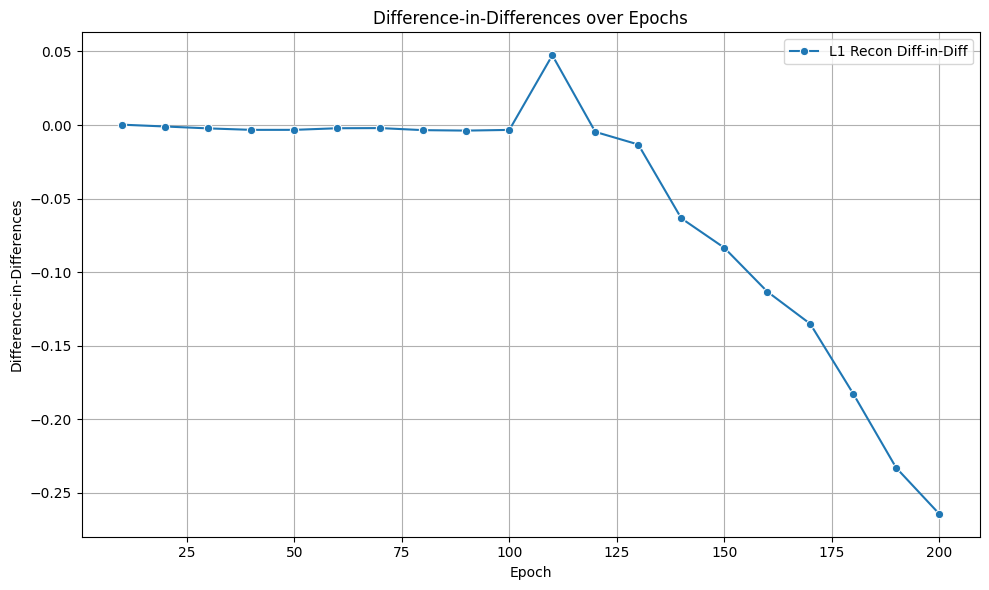

In [30]:
dffindff = []
# draw the epoch-development of the interaction effect
for epoch in range(10
                   , EPOCH_END + 1, 10):
    df_epoch = integrated_df.copy()
    df_epoch = df_epoch[df_epoch["epoch"] == epoch]
    df_epoch = df_epoch[df_epoch["train_lang"].isin(["L1", "L2"])]
    # predicted marginal means
    means = df_epoch.groupby(["L1_condition", "L2_condition", "freezing_condition"])["sil_score"].mean()

    # print("Difference-in-differences:", diff)
    dffindff.append({"epoch": epoch, 
                     "L1_rc": (means["Recon", "Class", "Freeze"] - means["Recon", "Recon", "Freeze"]) - (means["Recon", "Class", "NoFreeze"] - means["Recon", "Recon", "NoFreeze"]), })
                    #  "L1_cl": (means["Class", "Class", "Freeze"] - means["Class", "Recon", "Freeze"]) - (means["Class", "Class", "NoFreeze"] - means["Class", "Recon", "NoFreeze"])})

dffindff_df = pd.DataFrame(dffindff)
plt.figure(figsize=(10, 6))
sns.lineplot(data=dffindff_df, x="epoch", y="L1_rc", marker="o", label="L1 Recon Diff-in-Diff")
# sns.lineplot(data=dffindff_df, x="epoch", y="L1_cl", marker="s", label="L1 Class Diff-in-Diff")
plt.title("Difference-in-Differences over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Difference-in-Differences")
plt.grid(True)
plt.tight_layout()
plt.show()